<a href="https://colab.research.google.com/github/luvahuja16-byte/Hospital-Management-Dashboard/blob/main/Hospital_Management_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

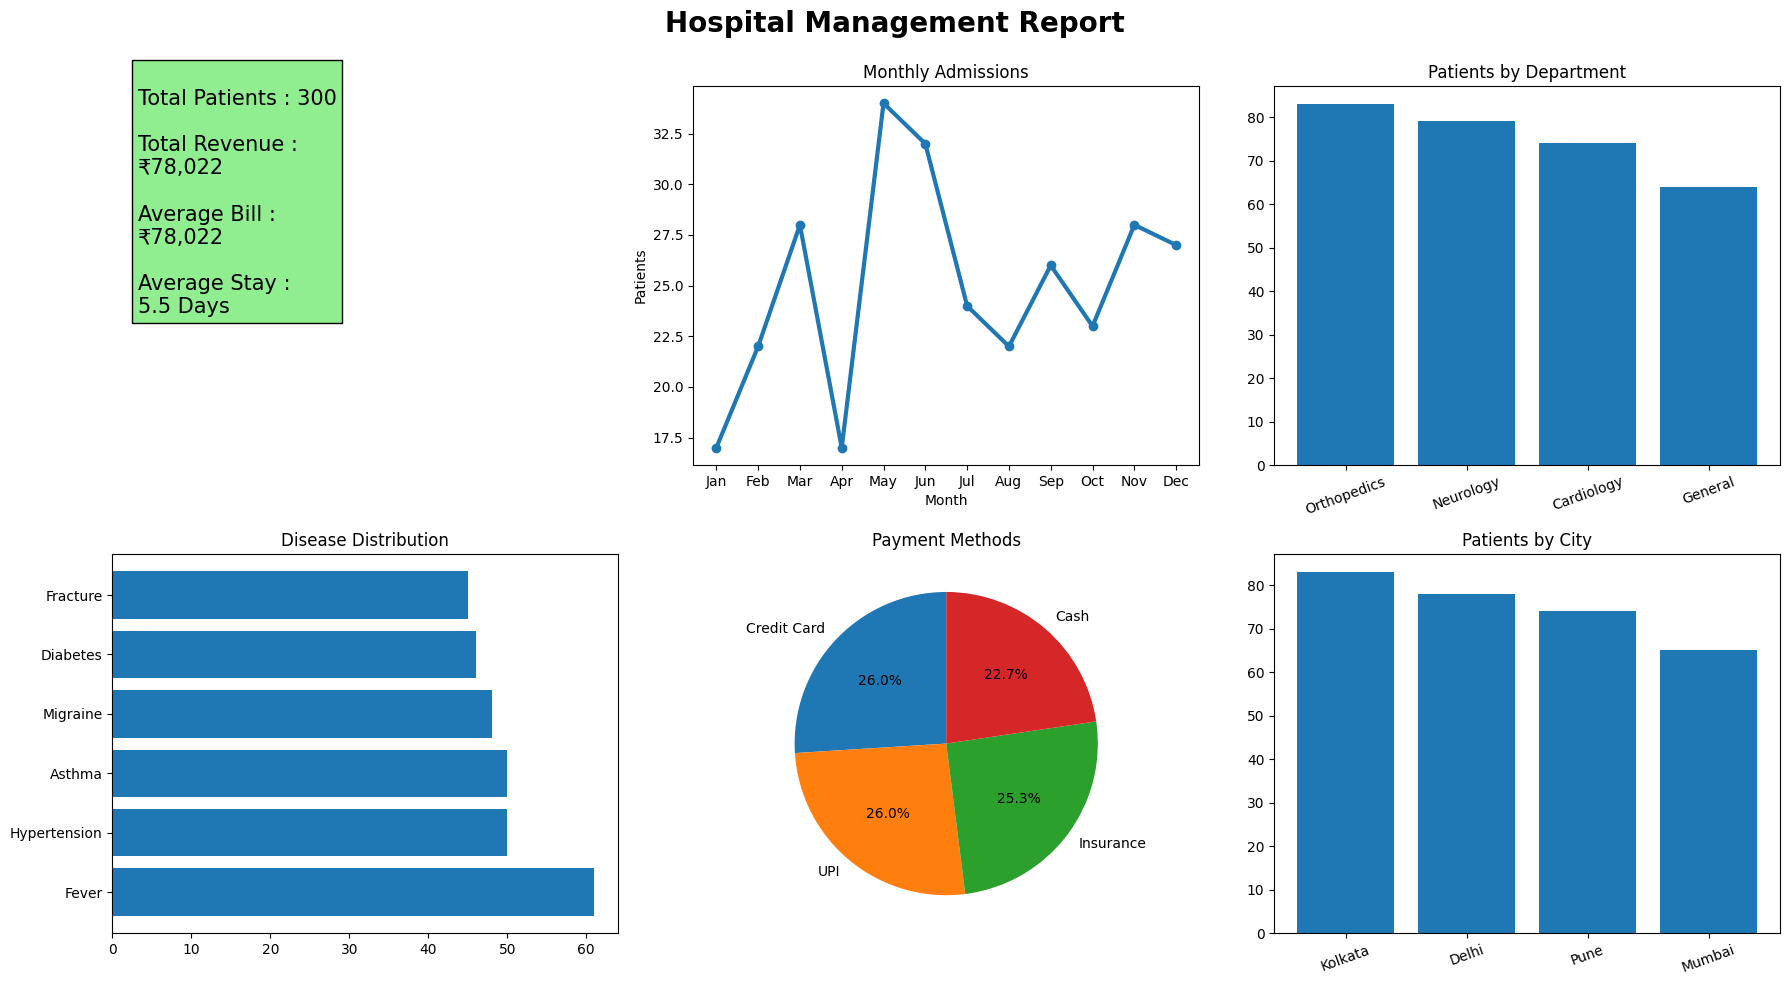


Top 10 Highest Bill Patients
--------------------------------------------------------------------------------
     Patient_ID Patient_Name       Disease      Doctor  Bill_Amount
55           56        Kabir      Diabetes   Dr. Singh       149841
178         179       Vivaan        Asthma   Dr. Gupta       148232
212         213         Diya         Fever   Dr. Singh       148089
294         295         Diya         Fever   Dr. Singh       147739
40           41         Diya  Hypertension   Dr. Singh       147335
131         132         Diya      Fracture   Dr. Singh       147310
63           64        Priya  Hypertension   Dr. Gupta       147089
272         273        Rahul  Hypertension  Dr. Sharma       147069
32           33       Vivaan      Fracture  Dr. Sharma       146841
81           82       Vivaan      Migraine    Dr. Khan       146399


Hospital Management Report
Total patients    : 300
Total Revenue     :₹23,406,464.00
Average Bill      :₹78,021.55
Highest Bill      :₹149,

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df=pd.read_csv("hospital_management_data.csv")

df["Admission_Date"] =pd.to_datetime(df["Admission_Date"])
df["Discharge_Date"] =pd.to_datetime(df["Discharge_Date"])

df["month"] =df["Admission_Date"].dt.strftime("%b")

month_order=[
    "Jan","Feb","Mar","Apr","May","Jun",
    "Jul","Aug","Sep","Oct","Nov","Dec"
]
bill_amount =np.array(df["Bill_Amount"])
stay_days =np.array(df["Hospital_Stay_Days"])
age= np.array(df["Age"])

total_revenue =np.sum(bill_amount)
average_bill =np.mean(bill_amount)
highest_bill =np.max(bill_amount)
lowest_bill =np.min(bill_amount)

average_age =np.mean(age)
average_stay =np.mean(stay_days)

monthly_patients =(
    df.groupby ("month")["Patient_ID"]
    .count()
    .reindex(month_order)
)
department_patients =(
    df["Department"]
    .value_counts()
)
disease_distribution =(
    df["Disease"]
    .value_counts()
)
doctor_patients=(
    df["Doctor"]
    .value_counts()
)
payment_distribution=(
    df["Payment_Method"]
    .value_counts()
)
city_patients=(
    df["City"]
    .value_counts()
)
top_bills =(
    df.sort_values(
        by="Bill_Amount",
        ascending=False
    )
    .head(10)
)
plt.figure(figsize=(18,10))
plt.suptitle(
    "Hospital Management Report",
    fontsize=20,
    fontweight="bold"
)
plt.subplot(2,3,1)
plt.axis("off")

summary =f"""
Total Patients : {len(df)}

Total Revenue :
₹{average_bill:,.0f}

Average Bill :
₹{average_bill:,.0f}

Average Stay :
{average_stay:.1f} Days """

plt.text(
    0.05,
    0.4,
    summary,
    fontsize=15,
    bbox=dict(facecolor="lightgreen")
)
plt.subplot(2,3,2)

plt.plot(
    monthly_patients.index,
    monthly_patients.values,
    marker="o",
    linewidth=3
)

plt.title("Monthly Admissions")
plt.xlabel("Month")
plt.ylabel("Patients")

plt.subplot(2,3,3)

plt.bar(
    department_patients.index,
    department_patients.values
)
plt.title("Patients by Department")
plt.xticks(rotation=20)

plt.subplot(2,3,4)

plt.barh(
    disease_distribution.index,
    disease_distribution.values
)
plt.title("Disease Distribution")
plt.subplot(2,3,5)
plt.pie(
     payment_distribution.values,
     labels=payment_distribution.index,
     autopct="%1.1f%%",
     startangle=90
 )
plt.title("Payment Methods")
plt.subplot(2,3,6)

plt.bar(
    city_patients.index,
    city_patients.values)
plt.title("Patients by City")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

print("\nTop 10 Highest Bill Patients")
print("-"*80)

print(
    top_bills[
        [
       "Patient_ID",
       "Patient_Name",
        "Disease",
        "Doctor",
        "Bill_Amount"
        ]
    ]
)

print("\n")
print("="*60)
print("Hospital Management Report")
print("="*60)

print("Total patients    :", len(df))
print("Total Revenue     :₹{:,.2f}".format(total_revenue))
print("Average Bill      :₹{:,.2f}".format(average_bill))
print("Highest Bill      :₹{:,.2f}".format(highest_bill))
print("Lowest Bill       :₹{:,.2f}".format(lowest_bill))
print("Average Age       :{:.2f} Years".format(average_age))
print("Average Stay      :{:.2f} Days".format(average_stay))

print("\nMost Common Disease")
print(disease_distribution.idxmax())

print("\nMost Visited Department")
print(department_patients.idxmax())

print("\nDoctor With Most Patients")
print(doctor_patients.idxmax())

print("\nMost Used Payment Method")
print(payment_distribution.idxmax())

print("\nCity With Most Patients")
print(city_patients.idxmax())